<a href="https://colab.research.google.com/github/iremozdemi/MLLM-VR-MA-TSP-Agent-Study/blob/main/CLASSIFIED_VR_MA_TSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- %100 SAF LLM BÖL-YÖNET BAŞLANGIÇ ÇÖZÜMÜ İŞLEMİ BAŞLATILIYOR ---
✅ JSON dosyasından 200 şehir koordinatı başarıyla ayıklandı ve okundu.

🚀 [Deneme 1/5] Global Çözüm Akışı Başlatıldı...
🧩 [Böl ve Yönet] Merkez Noktalar Hesaplandı: X=2048.00, Y=1025.00
📊 Çeyrek Nokta Dağılımları: Q1: 55, Q2: 45, Q3: 54, Q4: 45
🤖 [Çeyrek 1/4] Görsel hazırlanıyor ve Gemini optimize ediyor...
⚠️ [Çeyrek 1] Çözüm esnasında API hatası: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   -> Çeyrek 1 Alt Rotası Alındı. Eleman Sayısı: 55
🤖 [Çeyrek 2/4] Görsel hazırlanıyor ve Gemini optimize ediyor...
   -> Çeyrek 2 Alt Rotası Alındı. Eleman Sayısı: 45
🤖 [Çeyrek 3/4] Görsel hazırlanıyor ve Gemini optimize ediyor...
   -> Çeyrek 3 Alt Rotası Alındı. Eleman Sayısı: 54
🤖 [Çeyrek 4/4] Görsel hazırlanıyor ve Gemini optimize ediyor...
   -> Çeyrek 4 Alt Rotası Alındı. Elem

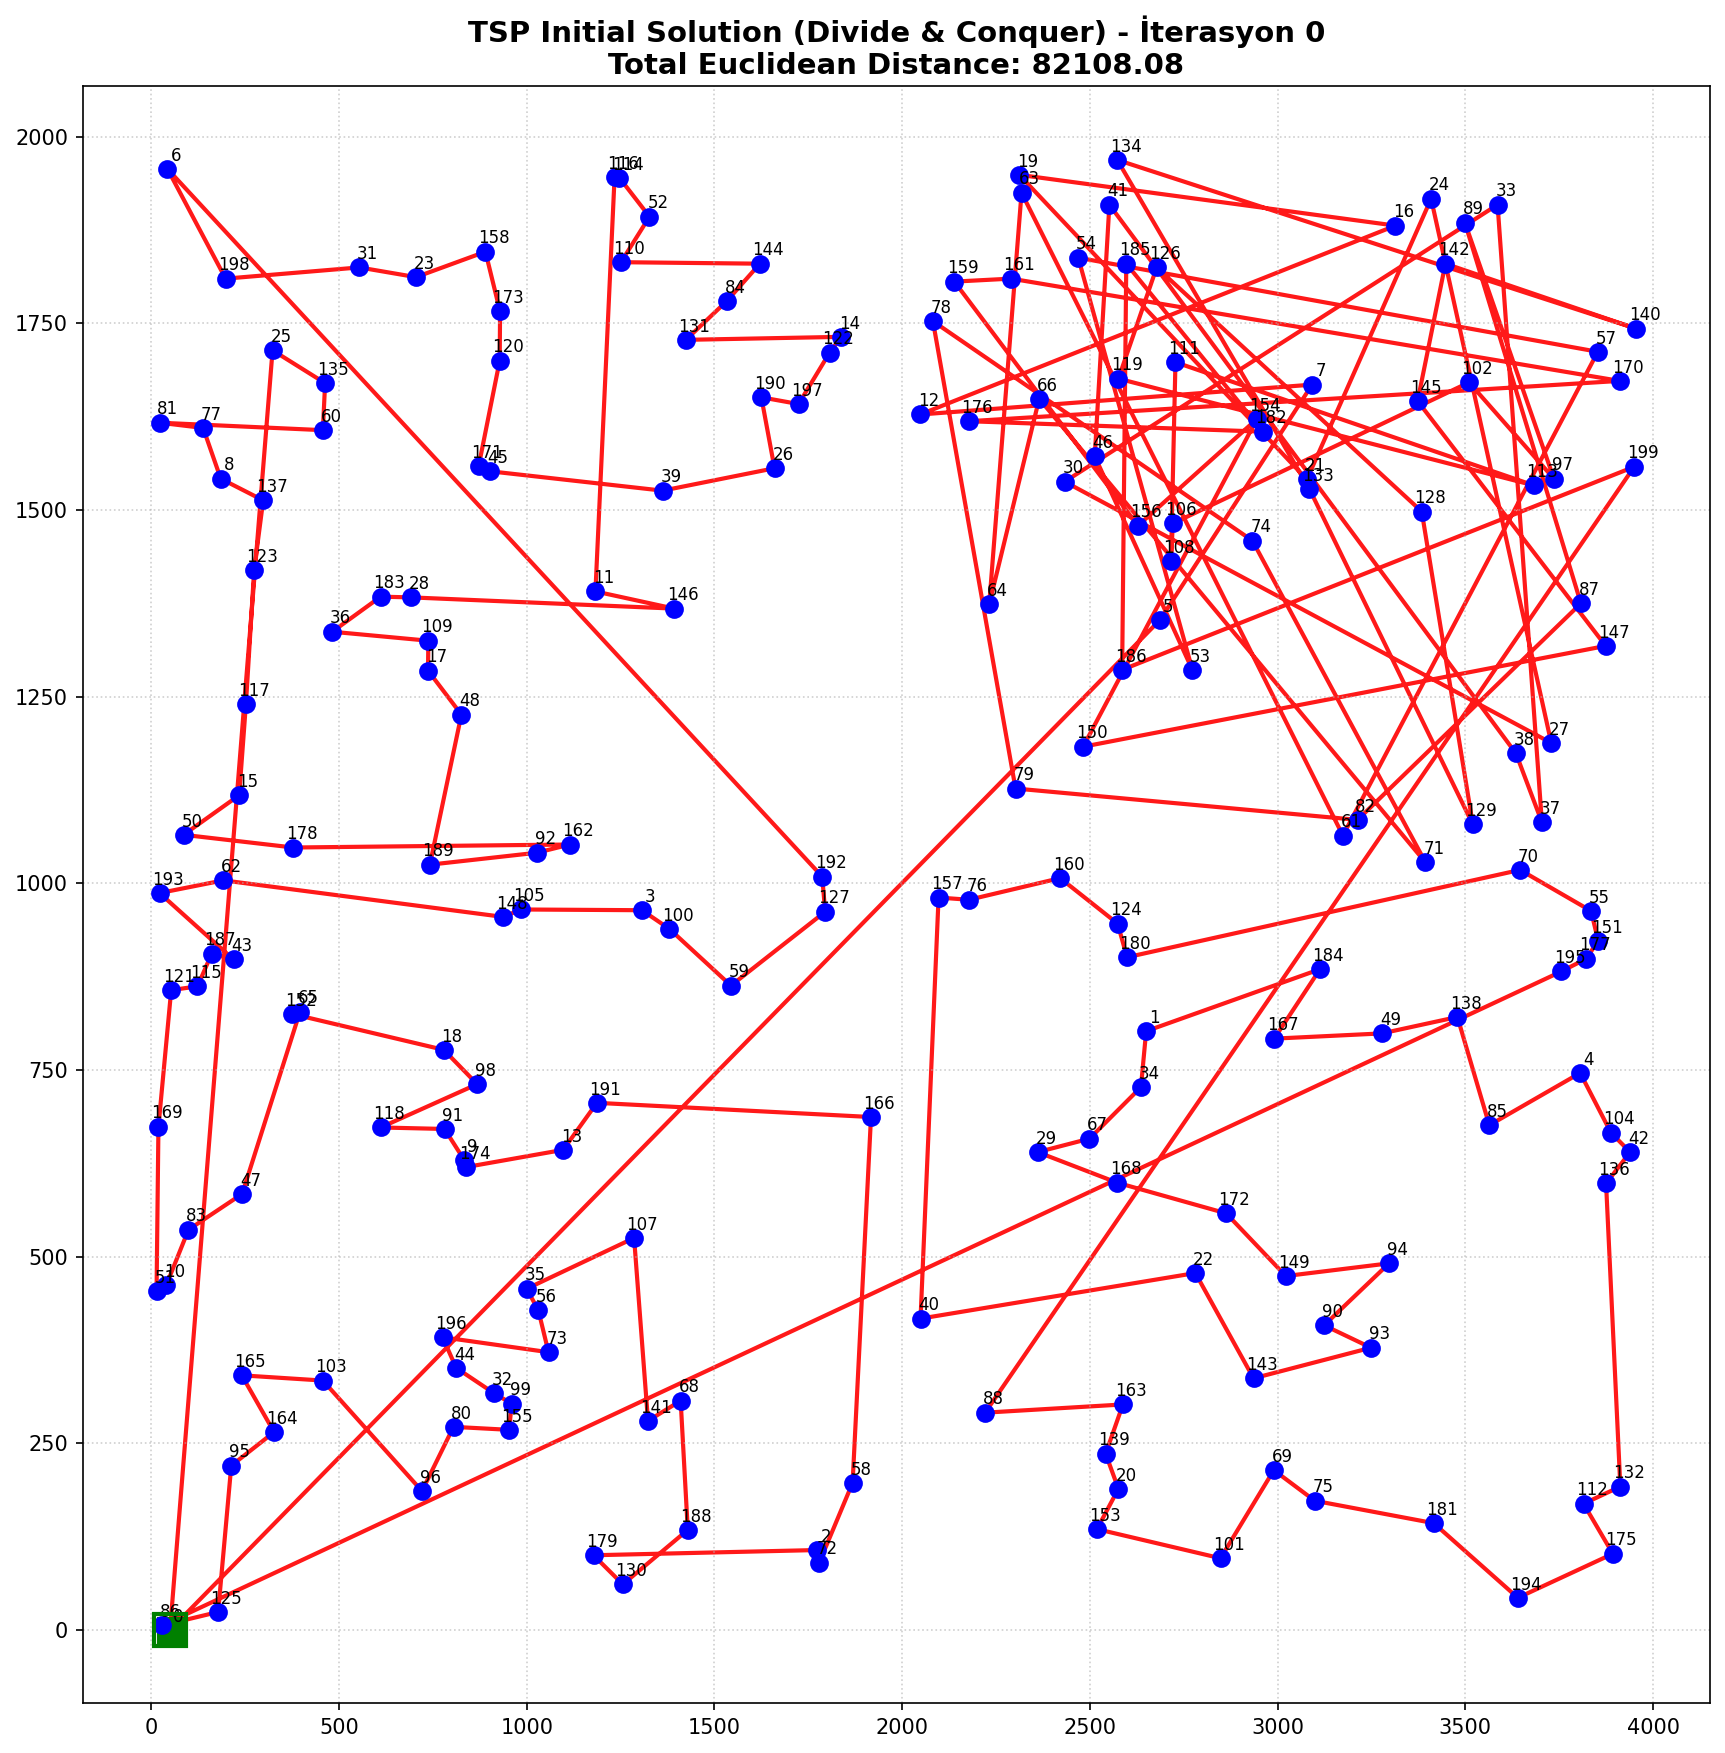

✅ ROTA GÖRSELİ BAŞARIYLA OLUŞTURULDU.

🚀 %100 SAF LLM JSON ÇIKTISI BAŞARIYLA YAZILDI: /content/drive/MyDrive/200 nokta/json_outputs/bench_route_output.json

--- İŞLEM TAMAMLANDI - SÜRE: 543.96 saniye ---


In [ ]:
# -*- coding: utf-8 -*-
"""
# tsp_initial_solver_v2.py - SAF LLM (GEMINI) VE TAM TUR GARANTİLİ GELİŞMİŞ BÖL-YÖNET SOLVER
"""
import matplotlib
matplotlib.use('Agg') # Kilitlenmeleri önlemek için arka plan çizim motoru
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import io
import re
import time
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from typing import List
from IPython.display import display, Image

# =================================================================
# --- API YAPILANDIRMASI ve SABİTLER ---
# =================================================================

try:
    client = genai.Client(api_key="YOUR API KEY")
except Exception as e:
    print(f"HATA: Gemini API istemcisi başlatılamadı: {e}")
    exit()

# --- Dosya Yolları ---

# =================================================================
# --- STRUCTURED OUTPUTS (YAPILANDIRILMIŞ ÇIKTI ŞEMALARI) ---
# =================================================================

class SubRouteResponse(BaseModel):
    sub_route: List[int] = Field(
        description="The optimized sequence of node indices belonging to this quadrant, ordered logically from entrance to exit."
    )

class RepairedRouteResponse(BaseModel):
    repaired_route: List[int] = Field(
        description="The complete and fixed route containing ALL required nodes exactly once, starting and ending at the depot."
    )

# =================================================================
# --- FONKSİYONLAR ---
# =================================================================

def calculate_total_euclidean_distance(cities, route_list):
    """Verilen rota listesi için toplam ÖKLİD (Düz Çizgi) mesafesini hesaplar."""
    if not route_list or len(route_list) < 2:
        return float('inf')

    temp_route_list = list(route_list)
    if temp_route_list[0] != temp_route_list[-1]:
        temp_route_list.append(temp_route_list[0])

    route_coords = cities[temp_route_list]
    total_distance = 0.0
    for i in range(len(route_coords) - 1):
        p1 = route_coords[i]
        p2 = route_coords[i+1]
        total_distance += np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    return total_distance


def generate_and_encode_image(points, sub_indices=None, title_suffix="", depot_index=0):
    """
    [ÇÖZÜM: GÖRSEL KALİTE & ÇÖZÜNÜRLÜK ARTIRMA]
    Görsel boyutunu 16x16 inç ve 150 DPI yaparak noktaların üst üste binmesini önler.
    Her düğüme yarı saydam beyaz arka planlı etiketler ekleyerek vizyon modelinin okumasını kolaylaştırır.
    """
    plt.close('all')
    fig, ax = plt.subplots(figsize=(16, 16), dpi=150)

    # Eğer alt küme (bölge) belirtilmemişse tüm noktaları çiz, belirtilmişse filtrele
    indices_to_plot = sub_indices if sub_indices is not None else list(range(len(points)))
    non_depot_indices = [i for i in indices_to_plot if i != depot_index]

    # Kullanıcı İsteklerine Göre Renklendirme: Düğümler Mavi, Depo Yeşil Kare
    ax.scatter(points[non_depot_indices, 0], points[non_depot_indices, 1], color='blue', s=60, zorder=2)
    if depot_index in indices_to_plot:
        ax.scatter(points[depot_index, 0], points[depot_index, 1], color='green', marker='s', s=200, zorder=3)

    # Çakışma ve Karışıklık Önleyici Gelişmiş Etiketlendirme
    for i in indices_to_plot:
        point = points[i]
        ax.annotate(
            str(i), (point[0], point[1]),
            textcoords="offset points", xytext=(3, 3),
            ha='center', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.15", fc="white", edgecolor="gray", alpha=0.7, linewidth=0.5)
        )

    ax.set_title(f"TSP Node Map - {title_suffix} (Nodes: {len(indices_to_plot)})", fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.set_xlim(points[:, 0].min() - 5, points[:, 0].max() + 5)
    ax.set_ylim(points[:, 1].min() - 5, points[:, 1].max() + 5)

    img_buffer = io.BytesIO()
    plt.savefig(img_buffer, format='png', bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    img_buffer.seek(0)
    return img_buffer.read()


def solve_quadrant_with_llm(image_bytes, quadrant_no, node_list, points):
    """[BÖL VE YÖNET] Belirli bir çeyrekteki noktaları Gemini Yapılandırılmış Çıktı ile sıraya dizer."""
    node_coords = {idx: points[idx].tolist() for idx in node_list}

    prompt = f"""
    ROLE & TASK:
    You are an expert algorithm designer analyzing Quadrant #{quadrant_no} of a larger Traveling Salesman Problem.
    Find the most logical, continuous, and shortest path sequence that visits EVERY node in this specific quadrant exactly once.

    MANDATORY NODES TO VISIT IN THIS QUADRANT:
    {list(node_list)}

    EXACT COORDINATES FOR REFERENCE [X, Y]:
    {json.dumps(node_coords)}

    CRITICAL CONSTRAINTS:
    1. Your output MUST include EVERY single node index listed above exactly once. No omissions, no duplicates.
    2. Sequence them smoothly so they trace a clear geometric path from one side of the quadrant to another without criss-crossing.
    """

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[types.Part.from_bytes(data=image_bytes, mime_type='image/png'), prompt],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=SubRouteResponse, # Yapılandırılmış çıktı garantisi
                temperature=0.1
            )
        )
        res_json = json.loads(response.text.strip())
        return res_json.get("sub_route", [])
    except Exception as e:
        print(f"⚠️ [Çeyrek {quadrant_no}] Çözüm esnasında API hatası: {e}")
        return list(node_list)


def repair_route_with_llm_enhanced(image_bytes, incomplete_route, missing_nodes, points, expected_length):
    """[ÇÖZÜM: GÜÇLENDİRİLMİŞ AKILLI TAMİR PROMPT'U]
    Eksik noktaların sadece indislerini değil, tam koordinatlarını da göndererek
    LLM'in geometrik olarak en yakın komşuların arasına ekleme yapmasını sağlar.
    """
    print(f"🔧 [Gelişmiş Tamir Modu] Eksik noktalar koordinat verileriyle LLM'e besleniyor: {list(missing_nodes)}")

    missing_coords = {int(node): points[node].tolist() for node in missing_nodes}

    repair_prompt = f"""
    You are optimizing a Traveling Salesman Problem route.
    In the merged global tour, some nodes were missed. We must achieve a perfect single tour.

    CURRENT INCOMPLETE ROUTE:
    {incomplete_route}

    MISSING NODES THAT MUST BE INTEGRATED:
    {list(missing_nodes)}

    COORDINATES OF THE MISSING NODES [X, Y]:
    {json.dumps(missing_coords)}

    TASK:
    Insert the missing nodes into the current incomplete route at the most mathematically and visually appropriate positions (between the closest existing neighbors) using both the map image and numerical coordinates.

    CRITICAL CONSTRAINTS:
    1. The final list length MUST be exactly {expected_length}.
    2. The route MUST start and end at node {depot_index}.
    3. ALL missing nodes must be integrated. Every node from 0 to {len(points)-1} must appear exactly once (except depot at start and end).
    """

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[types.Part.from_bytes(data=image_bytes, mime_type='image/png'), repair_prompt],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=RepairedRouteResponse,
                temperature=0.1
            )
        )
        res_json = json.loads(response.text.strip())
        return res_json.get("repaired_route", None)
    except Exception as e:
        print(f"⚠️ Gelişmiş tamir denemesi başarısız oldu: {e}")
        return None


def divide_and_conquer_tsp(cities):
    """
    Geometrik merkez hesaplayarak 150 noktayı 4 ana çeyreğe böler.
    Alt rotaları (Q1 -> Q4 -> Q3 -> Q2) düzeninde birleştirerek global döngü kırılmalarını önler.
    """
    non_depot_cities = cities[1:]
    mid_x = np.median(non_depot_cities[:, 0])
    mid_y = np.median(non_depot_cities[:, 1])

    print(f"🧩 [Böl ve Yönet] Merkez Noktalar Hesaplandı: X={mid_x:.2f}, Y={mid_y:.2f}")

    # 4 Çeyreğe Dağıtım (Depo hariç)
    q1_idx = [i for i in range(1, len(cities)) if cities[i, 0] >= mid_x and cities[i, 1] >= mid_y]
    q2_idx = [i for i in range(1, len(cities)) if cities[i, 0] < mid_x and cities[i, 1] >= mid_y]
    q3_idx = [i for i in range(1, len(cities)) if cities[i, 0] < mid_x and cities[i, 1] < mid_y]
    q4_idx = [i for i in range(1, len(cities)) if cities[i, 0] >= mid_x and cities[i, 1] < mid_y]

    print(f"📊 Çeyrek Nokta Dağılımları: Q1: {len(q1_idx)}, Q2: {len(q2_idx)}, Q3: {len(q3_idx)}, Q4: {len(q4_idx)}")

    sub_routes = {}
    for q_no, q_indices in enumerate([q1_idx, q2_idx, q3_idx, q4_idx], start=1):
        if not q_indices:
            sub_routes[q_no] = []
            continue
        print(f"🤖 [Çeyrek {q_no}/4] Görsel hazırlanıyor ve Gemini optimize ediyor...")
        img_bytes = generate_and_encode_image(cities, sub_indices=q_indices+[depot_index], title_suffix=f"Quadrant {q_no}", depot_index=depot_index)
        sub_route = solve_quadrant_with_llm(img_bytes, q_no, q_indices, cities)
        sub_routes[q_no] = sub_route
        print(f"   -> Çeyrek {q_no} Alt Rotası Alındı. Eleman Sayısı: {len(sub_route)}")

    # Mantıksal Coğrafi Birleştirme Akışı (Depo -> Q1 -> Q4 -> Q3 -> Q2 -> Depo)
    merged_route = [depot_index] + sub_routes[1] + sub_routes[4] + sub_routes[3] + sub_routes[2] + [depot_index]
    return merged_route


def get_gemini_optimal_route_pure_llm(image_bytes, cities, max_retries=5):
    """Ana orkestrasyon fonksiyonu."""
    all_indices = set(range(len(cities)))
    expected_length = len(cities) + 1

    for attempt in range(1, max_retries + 1):
        print(f"\n🚀 [Deneme {attempt}/{max_retries}] Global Çözüm Akışı Başlatıldı...")

        # Böl ve Yönet yöntemiyle rotayı parça parça çözüp birleştiriyoruz
        discovered_route = divide_and_conquer_tsp(cities)

        # Eksiklik kontrolü
        missing_nodes = all_indices - set(discovered_route)

        # Eğer eksik kalırsa Gelişmiş Koordinat Destekli Tamir Devreye Girer
        if missing_nodes and len(missing_nodes) <= 30:
            print(f"⚠️ {len(missing_nodes)} nokta birleştirmede eksik kaldı. Güçlendirilmiş tamir tetikleniyor...")
            repaired = repair_route_with_llm_enhanced(image_bytes, discovered_route, missing_nodes, cities, expected_length)
            if repaired:
                discovered_route = repaired
                missing_nodes = all_indices - set(discovered_route)

        if missing_nodes:
            print(f"⚠️ Geçersiz Rota: {len(missing_nodes)} adet nokta hala eksik. Yeniden deneniyor...")
            continue

        if len(discovered_route) != expected_length:
            print(f"⚠️ Rota uzunluğu hatalı (Mevcut: {len(discovered_route)}, Olması Gereken: {expected_length}). Yeniden deneniyor...")
            continue

        if discovered_route[0] != depot_index or discovered_route[-1] != depot_index:
            print(f"⚠️ Rota depoda ({depot_index}) başlayıp bitmiyor. Yeniden deneniyor...")
            continue

        print("✅ BAŞARILI: %100 Saf LLM Böl-Yönet akışı ve Yapılandırılmış Çıktı doğrulaması tamamlandı!")
        return discovered_route

    return None


def visualize_route(cities, route_list, distance, iteration_info, filename, depot_index):
    """Nihai rotayı kırmızı çizgileriyle birlikte düzgünce çizer ve diske kaydeder."""
    try:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(14, 14), dpi=150)

        temp_route_list = list(route_list)
        if temp_route_list[0] != temp_route_list[-1]:
            temp_route_list.append(temp_route_list[0])

        route_coords = cities[temp_route_list]
        # İstenen Kırmızı Rota Çizgisi
        ax.plot(route_coords[:, 0], route_coords[:, 1], 'r-', linewidth=2, alpha=0.9, zorder=1, label='ÖKLİD Rotası')

        # Düğümler Mavi, Depo Yeşil Kare Çizimi
        for i, (x, y) in enumerate(cities):
            color = 'blue' if i != depot_index else 'green'
            marker = 'o' if i != depot_index else 's'
            sizes = 8 if i != depot_index else 12
            ax.plot(x, y, marker, color=color, markersize=sizes, zorder=2)
            ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(4, 4), ha='center', fontsize=8)

        ax.plot(cities[depot_index, 0], cities[depot_index, 1], 's', color='green', markersize=15, fillstyle='none', markeredgewidth=2, zorder=4)

        title = (f"TSP Initial Solution (Divide & Conquer) - {iteration_info}\n"
                 f"Total Euclidean Distance: {distance:.2f}")

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)

        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, bbox_inches='tight')
        plt.close(fig)

        display(Image(filename=filename))
        print(f"✅ ROTA GÖRSELİ BAŞARIYLA OLUŞTURULDU.")
    except Exception as e:
        print(f"HATA: Görselleştirme aşamasında sorun çıktı: {e}")

# =================================================================
# --- ANA AKIŞ ---
# =================================================================

total_start_time = time.time()
print("--- %100 SAF LLM BÖL-YÖNET BAŞLANGIÇ ÇÖZÜMÜ İŞLEMİ BAŞLATILIYOR ---")

# 1. Veri Yükleme
try:
    with open(json_filename, 'r', encoding='utf-8') as f:
        json_content = json.load(f)

    extracted_nodes = [[node['x'], node['y']] for node in json_content['nodes']]
    cities = np.array(extracted_nodes, dtype=float)

    new_depot_coords = np.array([50.0, 0.0], dtype=float)
    if cities.shape[0] > depot_index:
        cities[depot_index] = new_depot_coords
    print(f"✅ JSON dosyasından {len(cities)} şehir koordinatı başarıyla ayıklandı ve okundu.")
except Exception as e:
    print(f"HATA: JSON okunamadı: {e}")
    exit()

# 2. Ana Görsel Hazırlama (Global Tamirlerde Kullanılmak Üzere)
image_bytes = generate_and_encode_image(cities, title_suffix="Global Map", depot_index=depot_index)

# 3. Gelişmiş API Çağrısı (Böl ve Yönet + Yapılandırılmış Çıktı + Tamir)
route_list = get_gemini_optimal_route_pure_llm(image_bytes, cities)

# 4. KESİN KONTROL VE DURDURMA
if not route_list:
    print("\n❌ [KRİTİK HATA] Gemini deneme sınırları içerisinde geçerli bir rota üretemedi.")
    exit()

# 5. Mesafe Hesaplama ve Çizim
total_euclidean_distance = calculate_total_euclidean_distance(cities, route_list)
print(f"\nHesaplanan Rota Sırası: {route_list}")
print(f"Uğranan Toplam Nokta Sayısı: {len(set(route_list))}")
print(f"Hesaplanan Toplam Mesafe (Öklid): {total_euclidean_distance:.2f}")

visualize_route(cities, route_list, total_euclidean_distance, "İterasyon 0", output_plot_filename, depot_index)

# 6. İkinci Script (Metaheuristic/Thesis) İçin JSON Çıktısı Üretme
output_data = {
    "cities_coordinates": cities.tolist(),
    "initial_route": route_list,
    "initial_distance_EUCLIDEAN": total_euclidean_distance,
    "depot_index": depot_index,
    "current_image_path": output_plot_filename
}

try:
    os.makedirs(os.path.dirname(initial_output_json), exist_ok=True)
    with open(initial_output_json, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, indent=4)
    print(f"\n🚀 %100 SAF LLM JSON ÇIKTISI BAŞARIYLA YAZILDI: {initial_output_json}")
except Exception as e:
    print(f"HATA: Veri kaydedilemedi: {e}")

print(f"\n--- İŞLEM TAMAMLANDI - SÜRE: {time.time() - total_start_time:.2f} saniye ---")